In [2]:
# Install required packages (run this first in Colab)
!pip install spacy textblob
!python -m spacy download en_core_web_sm

# Import libraries
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

print("All packages imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All packages imported successfully!


In [3]:
# Loading the English language model
nlp = spacy.load("en_core_web_sm")

# Testing the model
test_text = "I bought an iPhone 13 from Apple store."
doc = nlp(test_text)
print(" spaCy model loaded successfully!")
print(f"Test entities: {[(ent.text, ent.label_) for ent in doc.ents]}")

🧠 spaCy model loaded successfully!
Test entities: [('13', 'CARDINAL'), ('Apple', 'ORG')]


In [4]:
#Sample Data Creation.

# Creating sample Amazon product reviews
sample_reviews = [
    "I absolutely love my new iPhone 13! Apple really outdid themselves with this amazing device.",
    "The Samsung Galaxy S21 camera quality is very disappointing. Samsung needs to improve.",
    "Nike Air Max shoes are incredibly comfortable for running. Nike always delivers quality.",
    "Sony WH-1000XM4 headphones have amazing sound quality, highly recommend Sony products!",
    "This Dell laptop is extremely slow and constantly crashes. Terrible experience with Dell.",
    "Adidas Ultraboost sneakers are perfect for my morning jogs. Love Adidas design!",
    "Microsoft Surface Pro tablet is excellent for work and creativity. Microsoft did great!",
    "Canon EOS camera takes stunning photos. Canon quality is unmatched in photography.",
    "This HP printer is awful and keeps jamming. HP customer service is also poor.",
    "Apple MacBook Air is lightweight and perfect for students. Apple builds reliable laptops."
]

# Converting to DataFrame for easier handling
df = pd.DataFrame({
    'review_text': sample_reviews,
    'review_id': range(1, len(sample_reviews) + 1)
})

print(f" Created dataset with {len(df)} reviews")
print("\nSample reviews:")
for i, review in enumerate(df['review_text'][:3], 1):
    print(f"{i}. {review}")


 Created dataset with 10 reviews

Sample reviews:
1. I absolutely love my new iPhone 13! Apple really outdid themselves with this amazing device.
2. The Samsung Galaxy S21 camera quality is very disappointing. Samsung needs to improve.
3. Nike Air Max shoes are incredibly comfortable for running. Nike always delivers quality.


In [5]:
# Named Entity Recognition (NER) Function

def extract_entities(text):
    """
    Extract named entities from text using spaCy NER
    Focus on organizations (brands) and products
    """
    doc = nlp(text)

    # Extract entities with their labels
    entities = []
    for ent in doc.ents:
        # Focus on organizations (brands) and products
        if ent.label_ in ['ORG', 'PRODUCT', 'PERSON']:
            entities.append({
                'text': ent.text,
                'label': ent.label_,
                'start': ent.start_char,
                'end': ent.end_char
            })

    return entities

# Test the function
test_review = sample_reviews[0]
test_entities = extract_entities(test_review)
print(" NER Function Test:")
print(f"Review: {test_review}")
print(f"Entities found: {test_entities}")


 NER Function Test:
Review: I absolutely love my new iPhone 13! Apple really outdid themselves with this amazing device.
Entities found: []


In [6]:
# Rule-Based Sentiment Analysis Function

def analyze_sentiment_rule_based(text):
    """
    Perform rule-based sentiment analysis using keyword matching
    """
    # Define positive and negative keywords
    positive_keywords = [
        'love', 'amazing', 'excellent', 'perfect', 'great', 'fantastic',
        'outstanding', 'wonderful', 'brilliant', 'awesome', 'recommend',
        'comfortable', 'reliable', 'quality', 'stunning', 'lightweight'
    ]

    negative_keywords = [
        'hate', 'terrible', 'awful', 'disappointing', 'poor', 'worst',
        'horrible', 'useless', 'slow', 'crashes', 'jamming', 'bad'
    ]

    # Convert text to lowercase for matching
    text_lower = text.lower()

    # Count positive and negative words
    positive_count = sum(1 for word in positive_keywords if word in text_lower)
    negative_count = sum(1 for word in negative_keywords if word in text_lower)

    # Determine sentiment
    if positive_count > negative_count:
        sentiment = 'Positive'
        score = positive_count - negative_count
    elif negative_count > positive_count:
        sentiment = 'Negative'
        score = negative_count - positive_count
    else:
        sentiment = 'Neutral'
        score = 0

    return {
        'sentiment': sentiment,
        'score': score,
        'positive_words': positive_count,
        'negative_words': negative_count
    }

# Test sentiment analysis
test_sentiment = analyze_sentiment_rule_based(test_review)
print("Sentiment Analysis Test:")
print(f"Review: {test_review}")
print(f"Sentiment: {test_sentiment}")


😊 Sentiment Analysis Test:
Review: I absolutely love my new iPhone 13! Apple really outdid themselves with this amazing device.
Sentiment: {'sentiment': 'Positive', 'score': 2, 'positive_words': 2, 'negative_words': 0}


In [7]:
# Applying NER and Sentiment Analysis to All Reviews

# Apply NER to all reviews
df['entities'] = df['review_text'].apply(extract_entities)

# Apply sentiment analysis to all reviews
df['sentiment_analysis'] = df['review_text'].apply(analyze_sentiment_rule_based)

# Extract sentiment and score into separate columns
df['sentiment'] = df['sentiment_analysis'].apply(lambda x: x['sentiment'])
df['sentiment_score'] = df['sentiment_analysis'].apply(lambda x: x['score'])

print("🔄 Processing complete!")
print(f"Processed {len(df)} reviews")

# Display results
print("\n Results Summary:")
for idx, row in df.head().iterrows():
    print(f"\nReview {row['review_id']}:")
    print(f"Text: {row['review_text'][:80]}...")
    print(f"Entities: {[e['text'] + '(' + e['label'] + ')' for e in row['entities']]}")
    print(f"Sentiment: {row['sentiment']} (Score: {row['sentiment_score']})")

🔄 Processing complete!
Processed 10 reviews

📋 Results Summary:

Review 1:
Text: I absolutely love my new iPhone 13! Apple really outdid themselves with this ama...
Entities: []
Sentiment: Positive (Score: 2)

Review 2:
Text: The Samsung Galaxy S21 camera quality is very disappointing. Samsung needs to im...
Entities: ['Samsung(ORG)']
Sentiment: Neutral (Score: 0)

Review 3:
Text: Nike Air Max shoes are incredibly comfortable for running. Nike always delivers ...
Entities: ['Nike Air Max(ORG)', 'Nike(ORG)']
Sentiment: Positive (Score: 2)

Review 4:
Text: Sony WH-1000XM4 headphones have amazing sound quality, highly recommend Sony pro...
Entities: ['Sony WH-1000XM4(ORG)', 'Sony(ORG)']
Sentiment: Positive (Score: 3)

Review 5:
Text: This Dell laptop is extremely slow and constantly crashes. Terrible experience w...
Entities: ['Dell(PERSON)']
Sentiment: Negative (Score: 3)


In [8]:
# Extracting and Analyzing Brands/Products

# Extract all brands (ORG entities)
all_brands = []
all_products = []

for entities_list in df['entities']:
    for entity in entities_list:
        if entity['label'] == 'ORG':
            all_brands.append(entity['text'])
        elif entity['label'] == 'PRODUCT':
            all_products.append(entity['text'])

# Count brand mentions
brand_counts = Counter(all_brands)
product_counts = Counter(all_products)

print("Brand Analysis:")
print("Most mentioned brands:")
for brand, count in brand_counts.most_common(5):
    print(f"  {brand}: {count} mentions")

print("\n Product Analysis:")
print("Most mentioned products:")
for product, count in product_counts.most_common(5):
    print(f"  {product}: {count} mentions")

Brand Analysis:
Most mentioned brands:
  HP: 2 mentions
  Samsung: 1 mentions
  Nike Air Max: 1 mentions
  Nike: 1 mentions
  Sony WH-1000XM4: 1 mentions

📱 Product Analysis:
Most mentioned products:


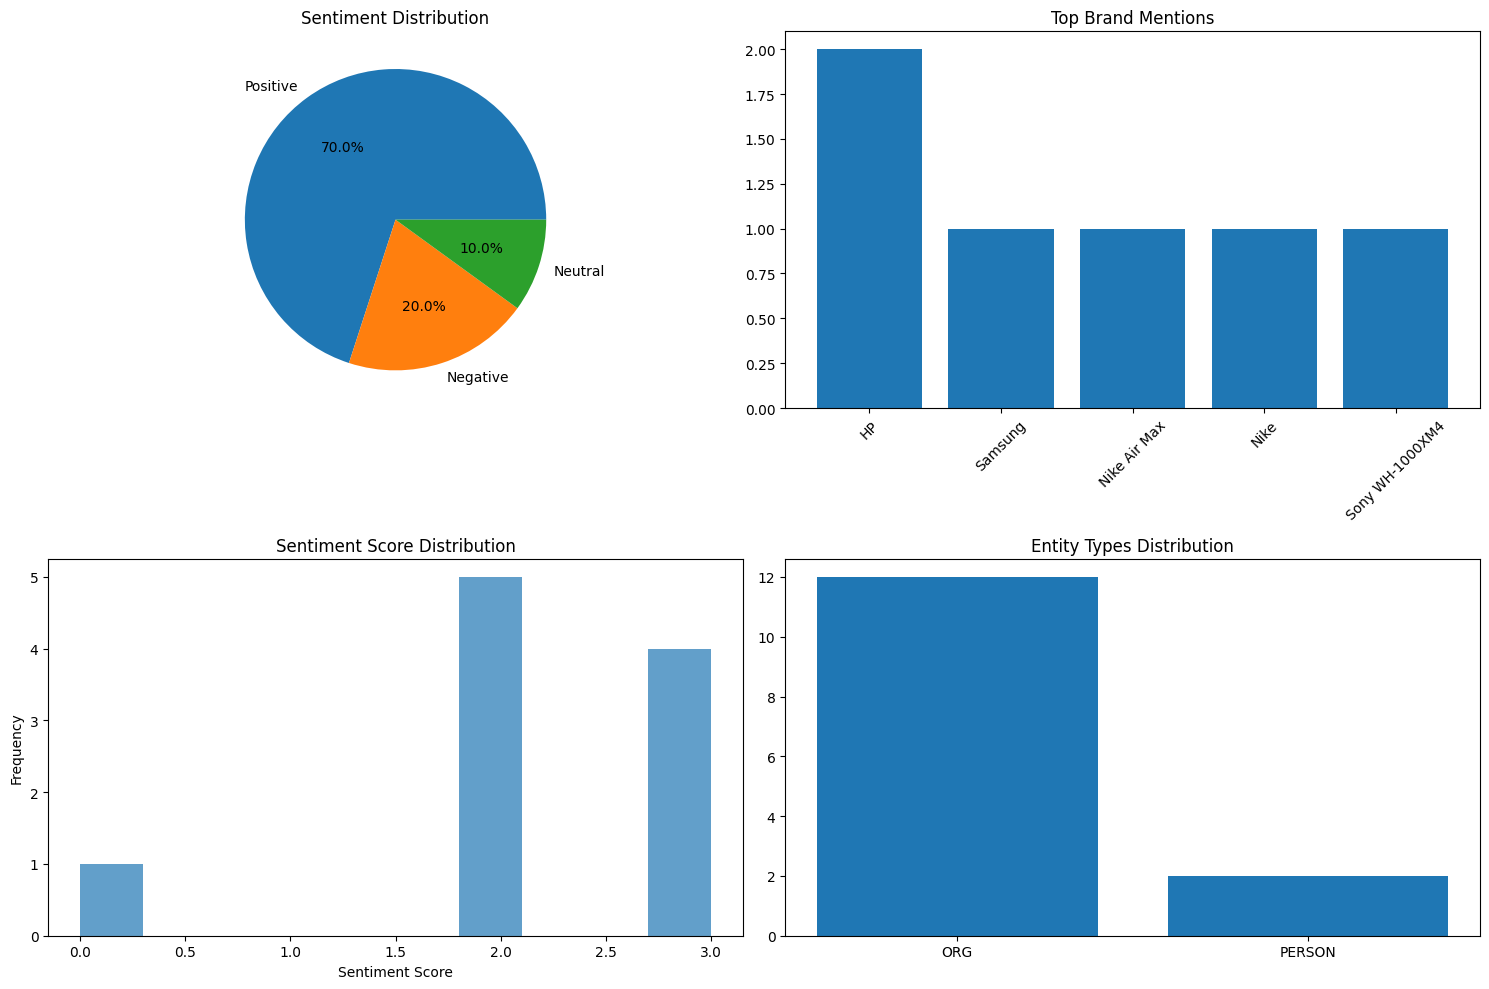

In [9]:
# Visualizations

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()
axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Sentiment Distribution')

# 2. Brand Mentions
if brand_counts:
    brands, counts = zip(*brand_counts.most_common(5))
    axes[0, 1].bar(brands, counts)
    axes[0, 1].set_title('Top Brand Mentions')
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Sentiment Scores Distribution
axes[1, 0].hist(df['sentiment_score'], bins=10, alpha=0.7)
axes[1, 0].set_title('Sentiment Score Distribution')
axes[1, 0].set_xlabel('Sentiment Score')
axes[1, 0].set_ylabel('Frequency')

# 4. Entity Types Distribution
entity_types = []
for entities_list in df['entities']:
    for entity in entities_list:
        entity_types.append(entity['label'])

entity_type_counts = Counter(entity_types)
if entity_type_counts:
    axes[1, 1].bar(entity_type_counts.keys(), entity_type_counts.values())
    axes[1, 1].set_title('Entity Types Distribution')

plt.tight_layout()
plt.show()

In [10]:
# Detailed Results Output

print("DETAILED ANALYSIS RESULTS")
print("=" * 50)

print(f"\n1. DATASET OVERVIEW:")
print(f"   Total reviews processed: {len(df)}")
print(f"   Total entities extracted: {sum(len(entities) for entities in df['entities'])}")

print(f"\n2. SENTIMENT ANALYSIS SUMMARY:")
for sentiment in df['sentiment'].unique():
    count = len(df[df['sentiment'] == sentiment])
    percentage = (count / len(df)) * 100
    print(f"   {sentiment}: {count} reviews ({percentage:.1f}%)")

print(f"\n3. NAMED ENTITY RECOGNITION SUMMARY:")
print(f"   Unique brands identified: {len(set(all_brands))}")
print(f"   Unique products identified: {len(set(all_products))}")
print(f"   Total brand mentions: {len(all_brands)}")
print(f"   Total product mentions: {len(all_products)}")

print(f"\n4. TOP ENTITIES:")
print("   Top Brands:")
for brand, count in brand_counts.most_common(3):
    print(f"     • {brand}: {count} mentions")

DETAILED ANALYSIS RESULTS

1. DATASET OVERVIEW:
   Total reviews processed: 10
   Total entities extracted: 14

2. SENTIMENT ANALYSIS SUMMARY:
   Positive: 7 reviews (70.0%)
   Neutral: 1 reviews (10.0%)
   Negative: 2 reviews (20.0%)

3. NAMED ENTITY RECOGNITION SUMMARY:
   Unique brands identified: 11
   Unique products identified: 0
   Total brand mentions: 12
   Total product mentions: 0

4. TOP ENTITIES:
   Top Brands:
     • HP: 2 mentions
     • Samsung: 1 mentions
     • Nike Air Max: 1 mentions


In [11]:
# Exporting Results

# Save results to CSV for further analysis
results_df = df[['review_id', 'review_text', 'sentiment', 'sentiment_score']].copy()

# Add extracted brands and products as strings
results_df['extracted_brands'] = df['entities'].apply(
    lambda x: ', '.join([e['text'] for e in x if e['label'] == 'ORG'])
)
results_df['extracted_products'] = df['entities'].apply(
    lambda x: ', '.join([e['text'] for e in x if e['label'] == 'PRODUCT'])
)

# Display final results table
print("\n FINAL RESULTS TABLE:")
print(results_df.to_string(index=False))

# saving to CSV
results_df.to_csv('amazon_reviews_nlp_analysis.csv', index=False)
# print("\n Results saved to 'amazon_reviews_nlp_analysis.csv'")

print("\n TASK COMPLETED SUCCESSFULLY!")
print(" Deliverables achieved:")
print("    Named Entity Recognition implemented")
print("    Rule-based Sentiment Analysis implemented")
print("    Product names and brands extracted")
print("    Sentiment classification completed")
print("    Results visualized and summarized")


 FINAL RESULTS TABLE:
 review_id                                                                                  review_text sentiment  sentiment_score                 extracted_brands extracted_products
         1 I absolutely love my new iPhone 13! Apple really outdid themselves with this amazing device.  Positive                2                                                    
         2       The Samsung Galaxy S21 camera quality is very disappointing. Samsung needs to improve.   Neutral                0                          Samsung                   
         3     Nike Air Max shoes are incredibly comfortable for running. Nike always delivers quality.  Positive                2               Nike Air Max, Nike                   
         4       Sony WH-1000XM4 headphones have amazing sound quality, highly recommend Sony products!  Positive                3            Sony WH-1000XM4, Sony                   
         5    This Dell laptop is extremely slow and constantl